# MLP Matrix Learning 2
This notebook trains a multi-layer perception network using triplet margin loss to understand similar commits, using embeddings of commits as training data and input. This version uses more training data compared to the previous version.

# Obtain commit hashes and embedding

In [1]:
import os
import glob
import json

commit_hash_folder = os.path.join(os.getcwd(), "data/commit_hashes")
commit_hashes_paths = glob.glob(os.path.join(commit_hash_folder,'*.json'))

commit_hashes_paths

['/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_flink.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_calcite.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_hive.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_camel.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_ignite.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_hadoop.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_cassandra.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_accumulo.json',
 '/Users/savirarama/Documents/Embedding-Clustering-Visualization/data/commit_hashes/commit_hashes_amba

### Concatenate lists of commit hashes

In [2]:
commit_hashes = []

for path in commit_hashes_paths:
    with open(path, 'r') as file:
        commit_hash = json.load(file)
    for hash in commit_hash:
        commit_hashes.append(hash)
        

In [3]:
len(commit_hashes)

41219

### Concatenate list of embeddings

In [4]:
import numpy as np

embedding_folder = os.path.join(os.getcwd(), "data/initial_embedding")
embedding_paths = glob.glob(os.path.join(embedding_folder, '*.npy'))

embeddings = np.load(embedding_paths[0])

for path in embedding_paths[1:]:
    embedding = np.load(path)
    embeddings = np.vstack((embeddings, embedding))

In [5]:
embeddings.shape

(41219, 768)

## Create training dataset

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


class TripleCommitDataset(Dataset):
    def __init__(self, anchors, positive, negative):
        self.anchors = torch.FloatTensor(anchors)
        self.positive = torch.FloatTensor(positive)
        self.negative = torch.FloatTensor(negative)
        
        # # Normalize the embeddings
        # self.anchors = nn.functional.normalize(self.anchors, p=2, dim=1)
        # self.positive = nn.functional.normalize(self.positive, p=2, dim=1)
        # self.negative = nn.functional.normalize(self.negative, p=2, dim=1)

    def __len__(self):
        return len(self.anchors)

    def __getitem__(self, idx):
        anchor = self.anchors[idx]
        pos = self.positive[idx]
        neg = self.negative[idx]
        return anchor, pos, neg
    

In [7]:
import json
triplets_dataset_path = 'data/triplets_till_ignite.json'
with open(triplets_dataset_path, 'r') as file:
    triplets_data = json.load(file)

anchors = [entry['anchor'] for entry in triplets_data]
positives = [entry['positive'] for entry in triplets_data]
negatives = [entry['negative'] for entry in triplets_data]




In [8]:
anchors_embeddings = [embeddings[commit_hashes.index(anchor)] 
                      for anchor in anchors]

positives_embeddings = [embeddings[commit_hashes.index(pos)] 
                        for pos in positives]

negatives_embeddings = [embeddings[commit_hashes.index(neg)] 
                        for neg in negatives]

In [9]:
print(f"{len(anchors_embeddings)} {len(positives_embeddings)} {len(negatives_embeddings)}" )

508 508 508


In [10]:
dataset = TripleCommitDataset(anchors_embeddings, positives_embeddings, negatives_embeddings)
dataloader = DataLoader(dataset, batch_size=3, shuffle=True, drop_last=True)

/var/folders/hq/mr_d9f8x11dfzc_f03z9xzbw0000gn/T/ipykernel_54368/498514304.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  self.anchors = torch.FloatTensor(anchors)


## Define MLP

In [11]:
class MLPEmbedding(nn.Module):
    def __init__(self, input_dim=768, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
                    nn.Linear(768, 512),
                    nn.BatchNorm1d(512),
                    nn.ReLU(),
                    nn.Linear(512, 256),
                    nn.BatchNorm1d(256),
                    nn.ReLU(),
                    nn.Linear(256, 64)
                )
    def forward(self, x):
        return self.net(x)
    
model = MLPEmbedding(768, 64)

## Setup Optimiser and Loss

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
triplet_loss = nn.TripletMarginLoss(margin=0.5)


## Train the MLP

In [13]:
import matplotlib.pyplot as plt

epochs = 100
losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for anchor, positive, negative in dataloader:
        optimizer.zero_grad()
        
        # anchor_out = model(anchor)
        # positive_out = model(positive)
        # negative_out = model(negative)

        #Normalize the output
        anchor_out = nn.functional.normalize(model(anchor), p=2, dim=1)
        positive_out = nn.functional.normalize(model(positive), p=2, dim=1)
        negative_out = nn.functional.normalize(model(negative), p=2, dim=1)
        
        loss_value = triplet_loss(anchor_out, positive_out, negative_out)

        loss_value.backward()
        optimizer.step()
        
        total_loss += loss_value.item()
    
    losses.append(total_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 1/100, Loss: 79.4667
Epoch 2/100, Loss: 75.8653
Epoch 3/100, Loss: 77.2335
Epoch 4/100, Loss: 72.4964
Epoch 5/100, Loss: 78.5098
Epoch 6/100, Loss: 76.5732
Epoch 7/100, Loss: 77.8632
Epoch 8/100, Loss: 75.6501
Epoch 9/100, Loss: 73.3673
Epoch 10/100, Loss: 77.3182
Epoch 11/100, Loss: 73.8815
Epoch 12/100, Loss: 74.4499
Epoch 13/100, Loss: 72.8982
Epoch 14/100, Loss: 75.9960
Epoch 15/100, Loss: 75.0177
Epoch 16/100, Loss: 75.5949
Epoch 17/100, Loss: 76.3093
Epoch 18/100, Loss: 73.2926
Epoch 19/100, Loss: 76.8678
Epoch 20/100, Loss: 74.9673
Epoch 21/100, Loss: 79.7927
Epoch 22/100, Loss: 72.8232
Epoch 23/100, Loss: 74.4093
Epoch 24/100, Loss: 79.6996
Epoch 25/100, Loss: 76.1333
Epoch 26/100, Loss: 75.6344
Epoch 27/100, Loss: 73.9025
Epoch 28/100, Loss: 79.2717
Epoch 29/100, Loss: 78.3123
Epoch 30/100, Loss: 78.1959
Epoch 31/100, Loss: 77.1388
Epoch 32/100, Loss: 71.5814
Epoch 33/100, Loss: 76.1858
Epoch 34/100, Loss: 74.9657
Epoch 35/100, Loss: 76.6587
Epoch 36/100, Loss: 76.7166
E

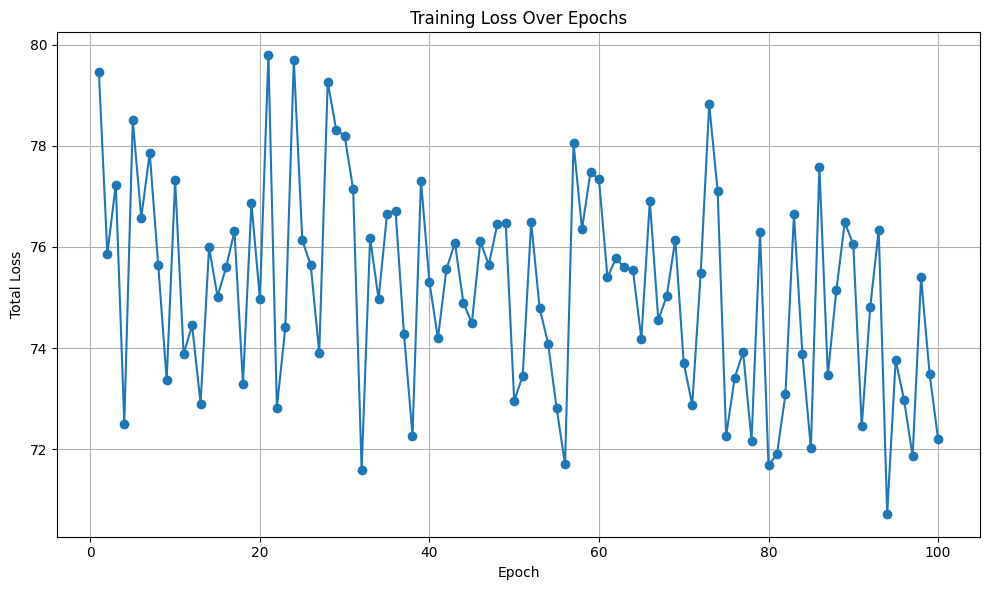

In [14]:
# Plotting the loss curve after training
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='-')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Save model parameters
torch.save(model.state_dict(), "triplet_model.pth")
print("Model saved to triplet_model.pth")

Model saved to triplet_model.pth
